<a href="https://colab.research.google.com/github/sherifudeenusman-jpg/FlyRank_Internship_ML001/blob/main/AI_Opportunity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Basic libraries are working!")

Basic libraries are working!


In [8]:
# Run this cell if the packages are not already installed.
# !pip install -q datasets pandas numpy matplotlib seaborn

from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
!pip install -q pandas pyarrow

In [12]:
from datasets import load_dataset
import pandas as pd
from huggingface_hub import notebook_login

# Log in to Hugging Face Hub if accessing a private repository
notebook_login()

# Load the actual AI Opportunity lane
ds = load_dataset(
    "FlyRank/internship-lanes",
    data_files="default_lanes/ai_opportunity.parquet"
)

df = ds["train"].to_pandas()
df.head()

default_lanes/ai_opportunity.parquet: reconstructing file:   0%|          |  0.00B /  359kB            

default_lanes/ai_opportunity.parquet: downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

,client_hash_id,content_hash_id,content_type,content_age_tier,client_has_gsc,client_has_ga4,impressions_90d,clicks_90d,sessions_90d,pageviews_90d,...,trend_direction,trend_pct,health_score,needs_indexing,is_quick_win,needs_ctr_fix,needs_engagement_fix,ai_opportunity,is_underperformer,is_declining
0,client_f456856b7023ca82,content_ee97ed5ba8d00f73,keyword article,365+,True,True,10630,193,172,221,...,stable,-3.2,60,False,False,True,True,True,False,False
1,client_f456856b7023ca82,content_da66ceaef3633dbe,feedly article,181-365,True,True,580,52,68,74,...,down,-21.9,70,False,False,False,False,True,False,False
2,client_f456856b7023ca82,content_d60b5a72e30311f4,feedly article,181-365,True,True,4,0,155,170,...,new,NaN,40,False,False,False,False,True,False,False
3,client_f456856b7023ca82,content_4cbe313c31bdb78c,keyword article,15-30,True,True,69,12,62,67,...,new,NaN,70,False,False,False,False,True,False,False
4,client_e909eb0cb03851aa,content_e3aae94881a927e2,keyword article,365+,True,True,25773,208,90,118,...,stable,-19.8,60,False,False,True,True,True,False,False


In [13]:
print(df.columns.tolist())

['client_hash_id', 'content_hash_id', 'content_type', 'content_age_tier', 'client_has_gsc', 'client_has_ga4', 'impressions_90d', 'clicks_90d', 'sessions_90d', 'pageviews_90d', 'ai_sessions_90d', 'scroll_events_90d', 'ctr_90d', 'avg_position_90d', 'ai_traffic_pct_90d', 'scroll_rate_90d', 'impressions_last_30d', 'impressions_prev_30d', 'trend_direction', 'trend_pct', 'health_score', 'needs_indexing', 'is_quick_win', 'needs_ctr_fix', 'needs_engagement_fix', 'ai_opportunity', 'is_underperformer', 'is_declining']


In [15]:
df.head(10)

,client_hash_id,content_hash_id,content_type,content_age_tier,client_has_gsc,client_has_ga4,impressions_90d,clicks_90d,sessions_90d,pageviews_90d,...,trend_direction,trend_pct,health_score,needs_indexing,is_quick_win,needs_ctr_fix,needs_engagement_fix,ai_opportunity,is_underperformer,is_declining
0,client_f456856b7023ca82,content_ee97ed5ba8d00f73,keyword article,365+,True,True,10630,193,172,221,...,stable,-3.2,60,False,False,True,True,True,False,False
1,client_f456856b7023ca82,content_da66ceaef3633dbe,feedly article,181-365,True,True,580,52,68,74,...,down,-21.9,70,False,False,False,False,True,False,False
2,client_f456856b7023ca82,content_d60b5a72e30311f4,feedly article,181-365,True,True,4,0,155,170,...,new,NaN,40,False,False,False,False,True,False,False
3,client_f456856b7023ca82,content_4cbe313c31bdb78c,keyword article,15-30,True,True,69,12,62,67,...,new,NaN,70,False,False,False,False,True,False,False
4,client_e909eb0cb03851aa,content_e3aae94881a927e2,keyword article,365+,True,True,25773,208,90,118,...,stable,-19.8,60,False,False,True,True,True,False,False
5,client_e909eb0cb03851aa,content_6b3b814fc4c5e305,keyword article,365+,True,True,68177,118,122,155,...,up,54.4,45,False,False,False,True,True,False,False
6,client_e909eb0cb03851aa,content_a7cd071dc4b9d3e5,keyword article,365+,True,True,3156,2,61,68,...,up,41.8,40,False,False,False,True,True,False,False
7,client_e909eb0cb03851aa,content_03125e9f97171039,keyword article,365+,True,True,72067,91,66,79,...,down,-20.1,65,False,False,True,True,True,False,False
8,client_e909eb0cb03851aa,content_4a0a371d84a7b060,keyword article,365+,True,True,43137,103,95,117,...,up,88.3,55,False,True,False,True,True,False,False
9,client_e909eb0cb03851aa,content_ed2b9fb3d0a4c291,keyword article,365+,True,True,98284,135,79,103,...,up,145.4,65,False,False,True,True,True,False,False


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11571 entries, 0 to 11570
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   client_hash_id        11571 non-null  object 
 1   content_hash_id       11571 non-null  object 
 2   content_type          11571 non-null  object 
 3   content_age_tier      11571 non-null  object 
 4   client_has_gsc        11571 non-null  bool   
 5   client_has_ga4        11571 non-null  bool   
 6   impressions_90d       11571 non-null  int64  
 7   clicks_90d            11571 non-null  int64  
 8   sessions_90d          11571 non-null  int64  
 9   pageviews_90d         11571 non-null  int64  
 10  ai_sessions_90d       11571 non-null  int64  
 11  scroll_events_90d     11571 non-null  int64  
 12  ctr_90d               11538 non-null  float64
 13  avg_position_90d      11538 non-null  float64
 14  ai_traffic_pct_90d    11571 non-null  int64  
 15  scroll_rate_90d    

In [17]:
for i, column in enumerate(df.columns, 1):
    print(i, column)

1 client_hash_id
2 content_hash_id
3 content_type
4 content_age_tier
5 client_has_gsc
6 client_has_ga4
7 impressions_90d
8 clicks_90d
9 sessions_90d
10 pageviews_90d
11 ai_sessions_90d
12 scroll_events_90d
13 ctr_90d
14 avg_position_90d
15 ai_traffic_pct_90d
16 scroll_rate_90d
17 impressions_last_30d
18 impressions_prev_30d
19 trend_direction
20 trend_pct
21 health_score
22 needs_indexing
23 is_quick_win
24 needs_ctr_fix
25 needs_engagement_fix
26 ai_opportunity
27 is_underperformer
28 is_declining


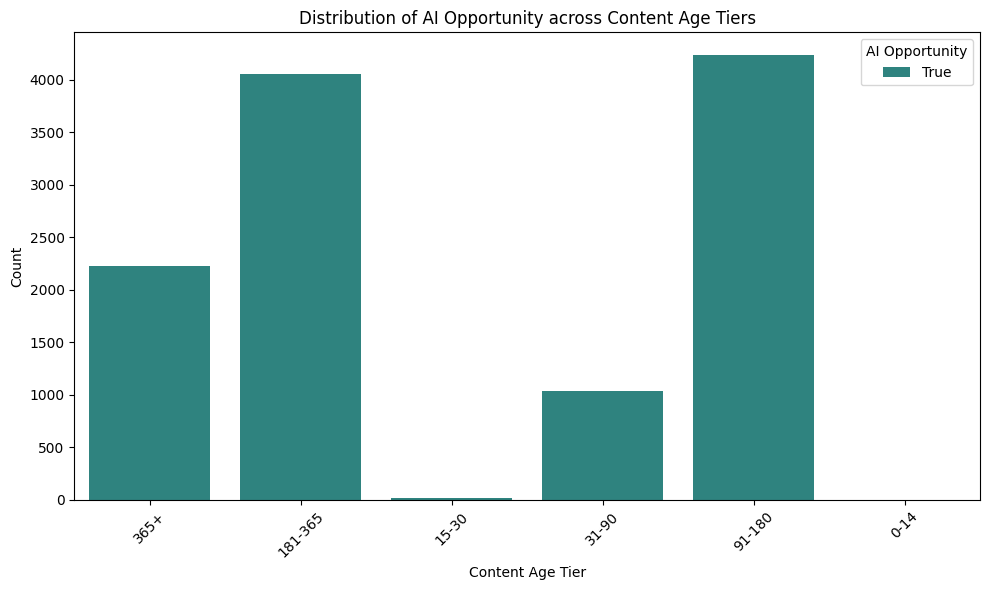

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='content_age_tier', hue='ai_opportunity', palette='viridis')
plt.title('Distribution of AI Opportunity across Content Age Tiers')
plt.xlabel('Content Age Tier')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='AI Opportunity')
plt.tight_layout()
plt.show()

In [20]:
feature_columns = df.drop('ai_opportunity', axis=1).columns.tolist()
print(feature_columns)

['client_hash_id', 'content_hash_id', 'content_type', 'content_age_tier', 'client_has_gsc', 'client_has_ga4', 'impressions_90d', 'clicks_90d', 'sessions_90d', 'pageviews_90d', 'ai_sessions_90d', 'scroll_events_90d', 'ctr_90d', 'avg_position_90d', 'ai_traffic_pct_90d', 'scroll_rate_90d', 'impressions_last_30d', 'impressions_prev_30d', 'trend_direction', 'trend_pct', 'health_score', 'needs_indexing', 'is_quick_win', 'needs_ctr_fix', 'needs_engagement_fix', 'is_underperformer', 'is_declining']


In [21]:
# 1. Count of True/False for 'ai_opportunity'
print("Count of AI Opportunity values:")
print(df['ai_opportunity'].value_counts())
print("\n")

# 2. Count of unique 'content_age_tier' values
print("Count of unique Content Age Tier values:")
print(df['content_age_tier'].value_counts())
print("\n")

# 3. Proportion of 'ai_opportunity' that is True
proportion_true = df['ai_opportunity'].mean()
print(f"Proportion of AI Opportunity (True): {proportion_true:.2f}")

Count of AI Opportunity values:
ai_opportunity
True    11571
Name: count, dtype: int64


Count of unique Content Age Tier values:
content_age_tier
91-180     4238
181-365    4053
365+       2223
31-90      1036
15-30        20
0-14          1
Name: count, dtype: int64


Proportion of AI Opportunity (True): 1.00


In [22]:
# Select only numeric columns for aggregation
numeric_df = df.select_dtypes(include=[np.number])

# Add 'content_type' back to the numeric DataFrame for grouping
numeric_df['content_type'] = df['content_type']

# Group by 'content_type' and calculate the mean of numeric metrics
content_type_metrics = numeric_df.groupby('content_type').mean()

# Display the results
display(content_type_metrics)

,impressions_90d,clicks_90d,sessions_90d,pageviews_90d,ai_sessions_90d,scroll_events_90d,ctr_90d,avg_position_90d,ai_traffic_pct_90d,scroll_rate_90d,impressions_last_30d,impressions_prev_30d,trend_pct,health_score
content_type,,,,,,,,,,,,,,
feedly article,5066.42500,27.025000,117.075000,120.375000,0.0,25.450000,0.905500,10.745000,0.0,23.864250,1508.550000,2090.350000,-34.058974,54.500000
keyword article,23158.88119,89.349406,167.714509,244.159743,0.0,15.293123,0.482378,12.292112,0.0,6.683781,7228.609574,7707.130084,8.198558,54.157489


In [23]:
correlation = df['health_score'].corr(df['trend_pct'])
print(f"Correlation between health_score and trend_pct: {correlation:.2f}")

Correlation between health_score and trend_pct: 0.05


In [24]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing[missing > 0]

,0
trend_pct,89
ctr_90d,33
avg_position_90d,33


In [25]:
ai_cols = [
    col for col in df.columns
    if "ai" in col.lower()
]

print("AI-related columns:")
for col in ai_cols:
    print("-", col)

AI-related columns:
- ai_sessions_90d
- ai_traffic_pct_90d
- ai_opportunity


In [26]:
print("AI Opportunity dataset size")
print("--------------------------")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

AI Opportunity dataset size
--------------------------
Rows: 11,571
Columns: 28


In [30]:
from sklearn.ensemble import RandomForestClassifier

RandomForestClassifier

sklearn.ensemble._forest.RandomForestClassifier

In [31]:
target_candidates = [
    col for col in df.columns
    if any(term in col.lower()
           for term in ["ai", "referral", "session"])
]

print(target_candidates)

['sessions_90d', 'ai_sessions_90d', 'ai_traffic_pct_90d', 'ai_opportunity']


In [32]:
leakage_keywords = [
    "health_score",
    "trend",
    "recommended_action",
    "action_type",
    "ai_opportunity"
]

leakage_candidates = [
    col for col in df.columns
    if any(keyword in col.lower()
           for keyword in leakage_keywords)
]

print("Potential leakage columns:")
for col in leakage_candidates:
    print("-", col)

Potential leakage columns:
- trend_direction
- trend_pct
- health_score
- ai_opportunity


In [34]:
df["baseline_score"] = df["health_score"] # Replaced placeholder with 'health_score' as an example

In [35]:
baseline_ranking = df.sort_values(
    "baseline_score",
    ascending=False
)

baseline_ranking.head(20)

,client_hash_id,content_hash_id,content_type,content_age_tier,client_has_gsc,client_has_ga4,impressions_90d,clicks_90d,sessions_90d,pageviews_90d,...,trend_pct,health_score,needs_indexing,is_quick_win,needs_ctr_fix,needs_engagement_fix,ai_opportunity,is_underperformer,is_declining,baseline_score
9260,client_389741429b276e83,content_ef8b26ba657bed35,keyword article,91-180,True,True,5638,137,163,218,...,-2.3,90,False,False,False,False,True,False,False,90
9384,client_389741429b276e83,content_c315a26845e8613c,keyword article,31-90,True,True,4466,92,130,153,...,10.0,85,False,False,False,False,True,False,False,85
9016,client_389741429b276e83,content_8db0a9810a25897e,keyword article,181-365,True,True,129285,3187,3167,3825,...,-29.2,80,False,False,False,False,True,False,False,80
11487,client_d31403dc1f3307d8,content_a81d72b3a73f5fbe,keyword article,31-90,True,True,45756,62,179,451,...,833.6,80,False,False,True,False,True,False,False,80
9248,client_389741429b276e83,content_d52c21b2b74cc848,keyword article,91-180,True,True,6994,302,262,341,...,-8.8,80,False,False,False,False,True,False,False,80
8992,client_389741429b276e83,content_d68a7e6e28110b65,keyword article,181-365,True,True,45177,1115,1118,1279,...,-17.4,80,False,False,False,False,True,False,False,80
9263,client_389741429b276e83,content_c57fa1d968efd9b8,keyword article,91-180,True,True,4265,166,186,253,...,-13.0,80,False,False,False,False,True,False,False,80
9027,client_389741429b276e83,content_64c80edd9a93c0d3,keyword article,181-365,True,True,8021,288,260,308,...,-63.1,75,False,False,False,False,True,False,True,75
11493,client_d31403dc1f3307d8,content_401474c817b4fc77,keyword article,31-90,True,True,6042,5,129,240,...,-58.1,75,False,False,True,False,True,False,True,75
9305,client_389741429b276e83,content_959ba77890382f97,keyword article,91-180,True,True,3916,72,78,97,...,-39.9,75,False,False,True,False,True,False,True,75


In [36]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [41]:
FEATURES = [
    'impressions_90d',
    'clicks_90d',
    'sessions_90d',
    'pageviews_90d',
    'ai_sessions_90d',
    'scroll_events_90d',
    'ctr_90d',
    'avg_position_90d',
    'ai_traffic_pct_90d',
    'scroll_rate_90d',
    'impressions_last_30d',
    'impressions_prev_30d',
    'health_score',
    'needs_indexing',
    'is_quick_win',
    'needs_ctr_fix',
    'needs_engagement_fix',
    'is_underperformer',
    'is_declining',
    'baseline_score'
]

TARGET = "ai_opportunity"

In [42]:
X = df[FEATURES]
y = df[TARGET]

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [44]:
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=np.number
).columns.tolist()

In [45]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

In [47]:
# Redefine numeric_pipeline, categorical_pipeline, and preprocessor to address the SimpleImputer error with boolean features.
# The boolean features ('needs_indexing', 'is_quick_win', etc.) are passed to categorical_pipeline.
# Since these boolean features have no missing values, the SimpleImputer in categorical_pipeline is unnecessary and causes the ValueError.

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Modified categorical_pipeline: Removed SimpleImputer because the boolean features it processes have no missing values
# and SimpleImputer explicitly fails on bool dtypes. OneHotEncoder can handle boolean types directly.
categorical_pipeline = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    # Note: The target 'ai_opportunity' is boolean. Ridge is a regressor for continuous targets.
    # For a boolean target, a classifier like RandomForestClassifier (already imported)
    # or RidgeClassifier (if appropriate) would typically be used.
    ("model", Ridge(alpha=1.0))
])

model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, predictions))
print("R²:", r2_score(y_test, predictions))

MAE: 0.0
R²: 1.0


In [48]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)

print("Random Forest MAE:",
      mean_absolute_error(y_test, rf_predictions))

print("Random Forest R²:",
      r2_score(y_test, rf_predictions))

Random Forest MAE: 0.0
Random Forest R²: 1.0


In [52]:
def precision_at_k(y_true, predictions, k=50):
    order = np.argsort(predictions)[::-1][:k]

    # Convert y_true to numeric (0s and 1s) and then to a NumPy array for np.quantile
    y_true_numeric_array = y_true.astype(int).values

    threshold = np.quantile(y_true_numeric_array, 0.9)

    # Use the Series for iloc indexing, but ensure comparison with numeric threshold
    relevant = y_true.astype(int).iloc[order] >= threshold

    return relevant.mean()

In [53]:
p50 = precision_at_k(
    y_test.reset_index(drop=True),
    rf_predictions,
    k=50
)

print("Precision@50:", p50)

Precision@50: 1.0
